In [1]:
# 04 — Explainability Analysis

#This notebook explains the predictions of the selected tuned XGBoost model using SHAP. Global feature contributions are examined first, followed by selected local explanations. SHAP values are interpreted as model-specific predictive contributions rather than causal effects.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [3]:
print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


In [4]:
DATA_PATH = Path("data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [5]:
from sklearn.model_selection import train_test_split

TARGET = "Diabetes_binary"

X = df.drop(columns=[TARGET])
y = df[TARGET]

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (56553, 21)
Test: (14139, 21)


In [6]:
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1
)

final_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [7]:
from sklearn.metrics import roc_auc_score

y_prob = final_model.predict_proba(X_test)[:, 1]

reproduced_auc = roc_auc_score(y_test, y_prob)

print("Reproduced test ROC-AUC:", round(reproduced_auc, 4))

Reproduced test ROC-AUC: 0.831


In [8]:
## SHAP Explainability Analysis
explainer = shap.TreeExplainer(final_model)

In [9]:
SHAP_SAMPLE_SIZE = min(5000, len(X_test))

X_shap = X_test.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

print(X_shap.shape)

(5000, 21)


In [10]:
shap_values = explainer(X_shap)

In [11]:
print("SHAP values shape:", shap_values.values.shape)
print("Feature data shape:", X_shap.shape)

SHAP values shape: (5000, 21)
Feature data shape: (5000, 21)


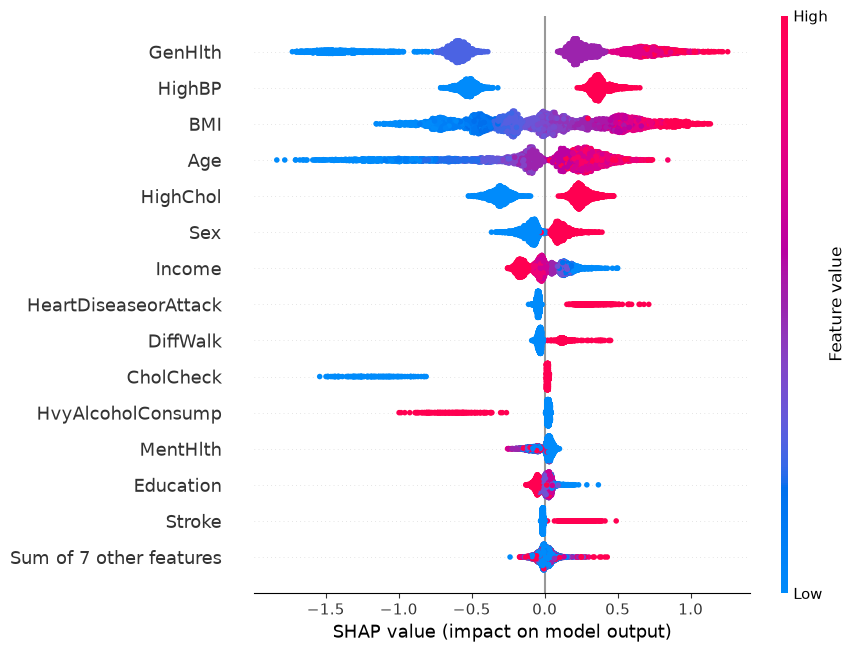

In [12]:
#### Global SHAP Feature Importance
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

plt.show()

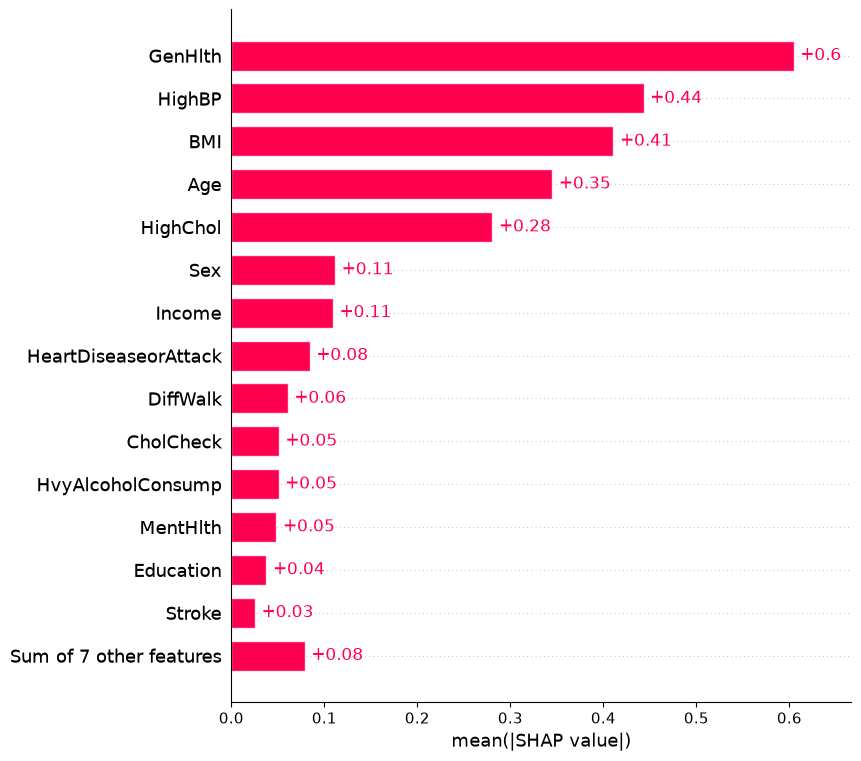

In [13]:
shap.plots.bar(
    shap_values,
    max_display=15
)

plt.show()


In [14]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_abs_SHAP": mean_abs_shap
}).sort_values(
    "Mean_abs_SHAP",
    ascending=False
)

shap_importance.head(15)

,Feature,Mean_abs_SHAP
13,GenHlth,0.604602
0,HighBP,0.443225
3,BMI,0.410725
18,Age,0.345056
1,HighChol,0.280711
17,Sex,0.111574
20,Income,0.109243
6,HeartDiseaseorAttack,0.084214
16,DiffWalk,0.060615
2,CholCheck,0.051023


In [15]:
top10_shap = shap_importance.head(10).copy()

top10_shap["Mean_abs_SHAP"] = (
    top10_shap["Mean_abs_SHAP"].round(4)
)

top10_shap

,Feature,Mean_abs_SHAP
13,GenHlth,0.6046
0,HighBP,0.4432
3,BMI,0.4107
18,Age,0.3451
1,HighChol,0.2807
17,Sex,0.1116
20,Income,0.1092
6,HeartDiseaseorAttack,0.0842
16,DiffWalk,0.0606
2,CholCheck,0.0510


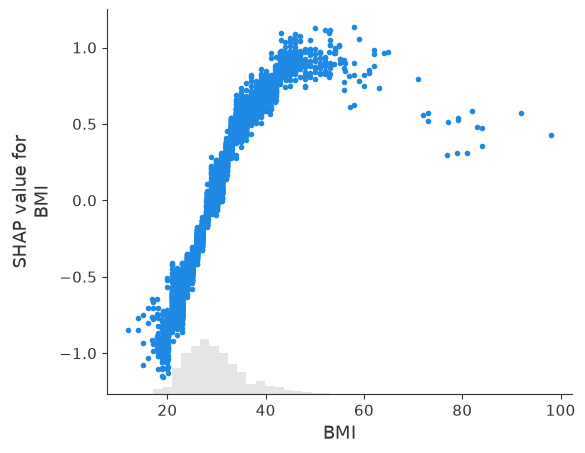

In [16]:
shap.plots.scatter(
    shap_values[:, "BMI"]
)

plt.show()

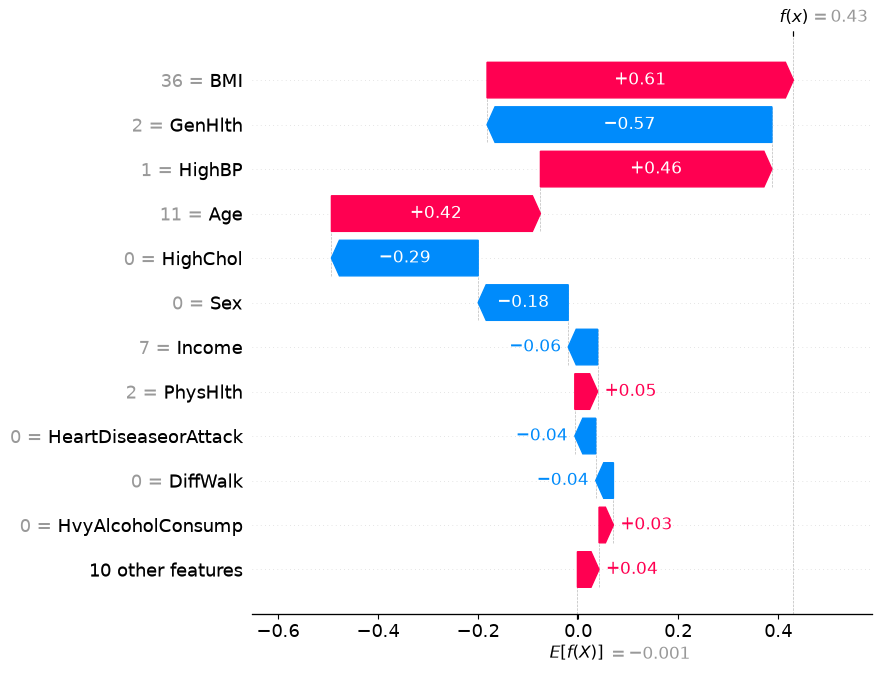

In [17]:
example_index = 0

shap.plots.waterfall(
    shap_values[example_index],
    max_display=12
)

plt.show()

In [ ]:
#####Explainability Summary. SHAP analysis identified GenHlth, HighBP, BMI, Age and HighChol as the dominant global contributors to XGBoost predictions. The beeswarm and dependence plots showed that contribution direction varied with feature values, while the waterfall plot demonstrated how multiple predictors combined within an individual prediction. Overall, the analysis provides a reproducible answer to RQ2 by quantifying both global and local model behaviour without making causal or diagnostic claims.